# Stellar Classification with the HYG Star Catalog

**Physics 20B Final Project (UCI)**

This project uses real astronomical data from the HYG star catalog to classify stars into broad spectral classes (O, B, A, F, G, K, M) using basic machine learning.

## Goals
- Load and clean a real star dataset.
- Explore relationships between color, magnitude, and luminosity.
- Train a classifier to predict a star's spectral class.
- Interpret model performance with confusion matrices and feature importance.

This notebook is intentionally written at a level appropriate for a second-year CS student with introductory astronomy knowledge.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

## 1) Load Dataset

Using the HYG catalog (v4.1) hosted in the public astronexus repository.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/astronexus/HYG-Database/main/hyg/CURRENT/hygdata_v41.csv"

df = pd.read_csv(DATA_URL)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (119626, 37)


,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,bayer,flam,con,comp,comp_primary,base,lum,var,var_min,var_max
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,NaN,NaN,NaN,1,0,NaN,1.000000,NaN,NaN,NaN
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,NaN,NaN,Psc,1,1,NaN,9.638290,NaN,NaN,NaN
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,NaN,NaN,Cet,1,2,NaN,0.392283,NaN,NaN,NaN
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,NaN,NaN,And,1,3,NaN,386.901132,NaN,NaN,NaN
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,NaN,NaN,Phe,1,4,NaN,9.366989,NaN,NaN,NaN


## 2) Basic Cleaning + Spectral Class Extraction

The `spect` column has detailed spectral strings (example: `G2V`, `K1III`).

For this project, we extract the first letter into one of the 7 major classes: **O, B, A, F, G, K, M**.

In [3]:
allowed_classes = list("OBAFGKM")

def extract_spectral_class(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    if not s:
        return np.nan
    c = s[0]
    return c if c in allowed_classes else np.nan

df["spec_class"] = df["spect"].apply(extract_spectral_class)

print("Unique extracted classes:", sorted(df["spec_class"].dropna().unique()))
print("Missing class labels:", df["spec_class"].isna().sum())

class_counts = df["spec_class"].value_counts(dropna=True).sort_index()
class_counts

Unique extracted classes: ['A', 'B', 'F', 'G', 'K', 'M', 'O']
Missing class labels: 3824


spec_class
A    18700
B    10416
F    25605
G    22798
K    32184
M     5834
O      265
Name: count, dtype: int64

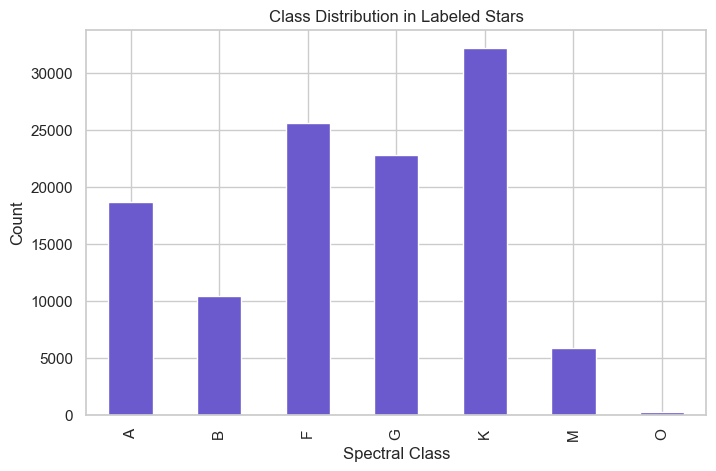

In [4]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar", color="slateblue")
plt.title("Class Distribution in Labeled Stars")
plt.xlabel("Spectral Class")
plt.ylabel("Count")
plt.show()

## 3) Build Features for Classification

We'll use a few physically meaningful fields:
- `ci` (color index, B-V proxy)
- `mag` (apparent magnitude)
- `absmag` (absolute magnitude)
- `lum` (luminosity relative to Sun)
- `dist` (distance in parsecs)

Then we split into train/test sets.

In [5]:
feature_cols = ["ci", "mag", "absmag", "lum", "dist"]

model_df = df.dropna(subset=["spec_class"]).copy()
X = model_df[feature_cols]
y = model_df["spec_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Labeled stars used:", len(model_df))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Labeled stars used: 115802
Train shape: (86851, 5)
Test shape: (28951, 5)


## 4) Train a Baseline Model

We use a `RandomForestClassifier` inside a simple preprocessing pipeline:
- median imputation for missing numeric values
- random forest model for multi-class classification

In [6]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=250,
        random_state=42,
        class_weight="balanced_subsample"
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=3))

Test accuracy: 0.7411

Classification report:



              precision    recall  f1-score   support

           A      0.730     0.749     0.739      4675
           B      0.685     0.636     0.659      2604
           F      0.781     0.828     0.804      6401
           G      0.698     0.622     0.658      5700
           K      0.769     0.832     0.799      8046
           M      0.669     0.521     0.586      1459
           O      0.095     0.030     0.046        66

    accuracy                          0.741     28951
   macro avg      0.632     0.603     0.613     28951
weighted avg      0.737     0.741     0.738     28951



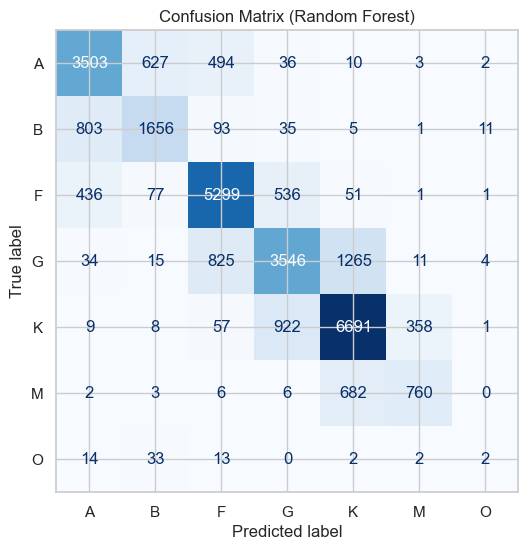

In [7]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Random Forest)")
plt.show()

## 5) Astronomy Visualization: H-R Style Diagram

Approximate Hertzsprung-Russell style view using color index (`B-V` proxy) versus absolute magnitude.

(Recall: lower absolute magnitude means brighter stars.)

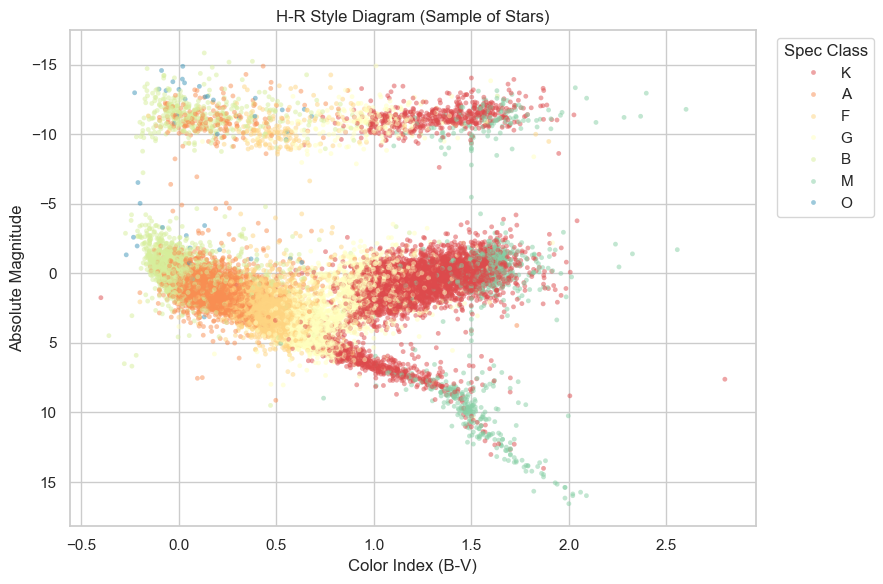

In [8]:
plot_df = model_df.dropna(subset=["ci", "absmag", "spec_class"]).sample(
    n=min(20000, len(model_df.dropna(subset=["ci", "absmag", "spec_class"]))),
    random_state=42
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df,
    x="ci",
    y="absmag",
    hue="spec_class",
    palette="Spectral",
    s=12,
    alpha=0.5,
    linewidth=0
)
plt.gca().invert_yaxis()
plt.title("H-R Style Diagram (Sample of Stars)")
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")
plt.legend(title="Spec Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

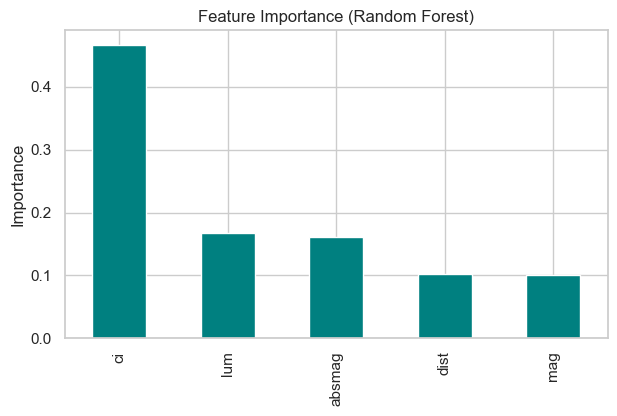

ci        0.466674
lum       0.167852
absmag    0.161941
dist      0.102966
mag       0.100567
dtype: float64

In [9]:
rf_model = rf_pipeline.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importances.plot(kind="bar", color="teal")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

importances

## 6) Discussion and Limitations

### What worked
- Major spectral classes can be predicted reasonably well using a small set of physical features.
- Color index and absolute magnitude are especially informative, which is consistent with stellar astrophysics.

### Limitations
- Labels come from catalog spectral strings and may be noisy/incomplete.
- Class imbalance (some classes are much rarer).
- We used a simplified class definition (first spectral letter only).

### Possible extensions
- Predict full subtype (e.g., G2V) instead of broad class.
- Add cross-validation and hyperparameter tuning.
- Combine with Gaia/SDSS data for richer feature engineering.
- Try unsupervised clustering to find unusual stars/outliers.